# Data Analysis

Беру данные из файла train.json с Kaggle - https://www.kaggle.com/competitions/two-sigma-connect-rental-listing-inquiries/data, смотрю размер таблицы и список столбцов, определяю целевую переменную — price. Провожу быструю проверку данных с помощью info(), describe(), corr(), смотрю, что пустых столбцов нет. После этого оставляю только эти признаки — bathrooms, bedrooms, interest_level и целевой столбец price для дальнейшей работы.

In [308]:
import pandas as pd
import numpy as np
from sklearn import datasets
import lightgbm as lgb
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [309]:
df = pd.read_json('data/train.json')
print("Размер изначального датафрейма")
df.shape

Размер изначального датафрейма


(49352, 15)

In [310]:
print("\nСписок колонок:")
df.columns.tolist()


Список колонок:


['bathrooms',
 'bedrooms',
 'building_id',
 'created',
 'description',
 'display_address',
 'features',
 'latitude',
 'listing_id',
 'longitude',
 'manager_id',
 'photos',
 'price',
 'street_address',
 'interest_level']

Целевой столбец: price

In [311]:
df.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [312]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [313]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Корреляция числовых столбцов:\n")
print(df[numeric_cols].corr())

Корреляция числовых столбцов:

            bathrooms  bedrooms  latitude  listing_id  longitude     price
bathrooms    1.000000  0.533446 -0.009657    0.000776   0.010393  0.069661
bedrooms     0.533446  1.000000 -0.004745    0.011968   0.006892  0.051788
latitude    -0.009657 -0.004745  1.000000    0.001712  -0.966807 -0.000707
listing_id   0.000776  0.011968  0.001712    1.000000  -0.000907  0.008090
longitude    0.010393  0.006892 -0.966807   -0.000907   1.000000 -0.000087
price        0.069661  0.051788 -0.000707    0.008090  -0.000087  1.000000


In [314]:
# проверка пустых колонок
empty_cols = df.isnull().sum() 
print(empty_cols[empty_cols > 0] if any(empty_cols > 0) else "Пустых колонок нет")

Пустых колонок нет


**Оставляем только 3 признака и целевой столбец** 

In [315]:
selected_cols_df = df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()
selected_cols_df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


In [316]:
selected_cols_df

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


# Statistical Data Analysis

**Target analysis.**  
  
Построила гистограмму целевой переменной price, посмотрела распределение, наличие выбросов. Затем построила boxplot(). Удалила строки с ценами ниже 1-го и выше 99-го перцентиля, после чего повторно построила гистограмму.

**Characteristics Analysis.**   
  
Проверила тип столбца interest_level, вывела уникальные значения и их количество. Закодировала уровни интереса числами (0, 1, 2). Построила гистограммы для bathrooms и bedrooms. 

**Complex analysis.**   
  
Построила корреляционную матрицу и тепловую карту, оценила взаимосвязи между признаками и целевой переменной. Затем построила три scatterplot, где по оси X — price, а по оси Y — каждый из признаков, чтобы визуально подтвердить или опровергнуть зависимость.

### Target

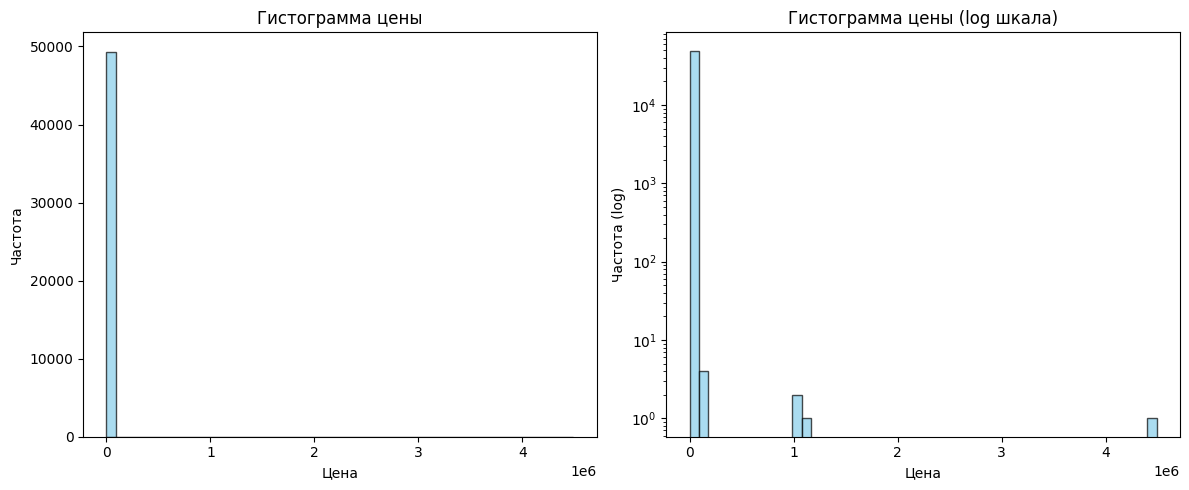

In [317]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(selected_cols_df['price'], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
plt.title('Гистограмма цены')
plt.xlabel('Цена')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.hist(selected_cols_df['price'], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
plt.yscale('log')
plt.title('Гистограмма цены (log шкала)')
plt.xlabel('Цена')
plt.ylabel('Частота (log)')

plt.tight_layout()
plt.show()

In [318]:
selected_cols_df['price'].describe()

count    4.935200e+04
mean     3.830174e+03
std      2.206687e+04
min      4.300000e+01
25%      2.500000e+03
50%      3.150000e+03
75%      4.100000e+03
max      4.490000e+06
Name: price, dtype: float64

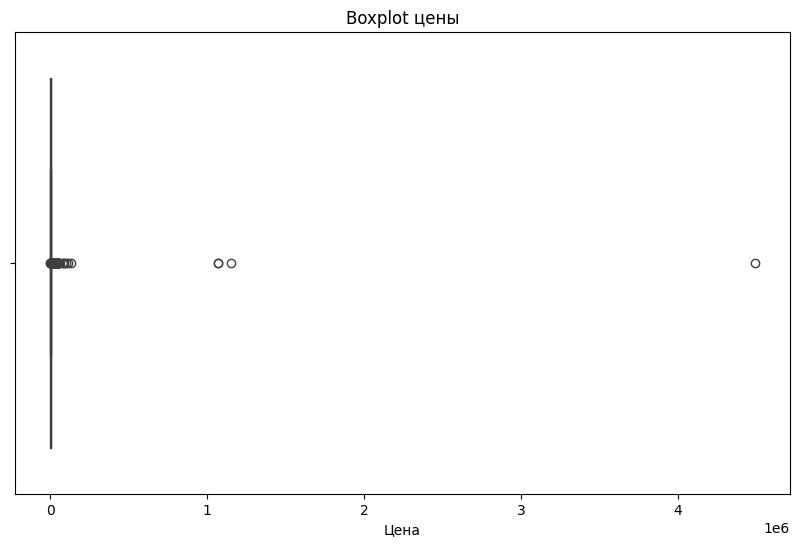

In [319]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=selected_cols_df['price'])
plt.title('Boxplot цены')
plt.xlabel('Цена')
plt.show()

In [320]:
print(f"Размер до удаления выбросов: {selected_cols_df.shape}")

price_lower = selected_cols_df['price'].quantile(0.01)
price_upper = selected_cols_df['price'].quantile(0.99)

Размер до удаления выбросов: (49352, 4)


In [321]:
print(f"1-й процентиль цены: {price_lower}")
print(f"99-й процентиль цены: {price_upper}")

1-й процентиль цены: 1475.0
99-й процентиль цены: 13000.0


**Вырезаем самые дорогие и самые дешевые квартиры, как выбросы**

In [322]:
df_clean = selected_cols_df[(selected_cols_df['price'] >= price_lower) & 
                            (selected_cols_df['price'] <= price_upper)]

print(f"Размер после удаления выбросов: {df_clean.shape}")
print(f"Удалено строк: {selected_cols_df.shape[0] - df_clean.shape[0]}")

Размер после удаления выбросов: (48379, 4)
Удалено строк: 973


Text(0, 0.5, 'Частота')

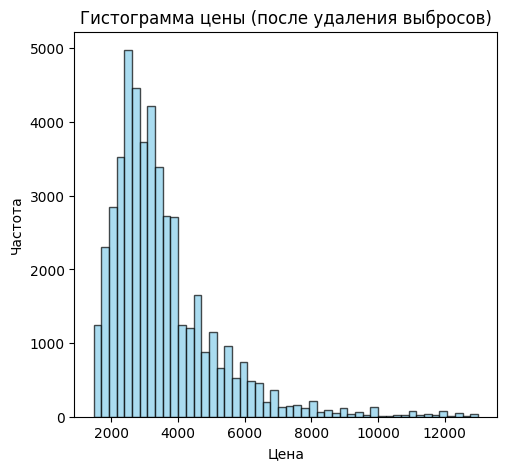

In [323]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_clean['price'], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
plt.title('Гистограмма цены (после удаления выбросов)')
plt.xlabel('Цена')
plt.ylabel('Частота')

In [324]:
print("\nСтатистика после удаления выбросов:\n")
print(df_clean['price'].describe())


Статистика после удаления выбросов:

count    48379.000000
mean      3538.636888
std       1597.663167
min       1475.000000
25%       2500.000000
50%       3150.000000
75%       4065.000000
max      13000.000000
Name: price, dtype: float64


### Characteristics

In [325]:
print(f"Тип данных колонки 'interest_level': {type(df_clean['interest_level'].iloc[0])}")

print("\nЗначения в колонке 'interest_level':")
print(df_clean['interest_level'].value_counts())

print("\nКоличество записей для каждого значения:")
for value, count in df_clean['interest_level'].value_counts().items():
    print(f"{value}: {count} записей ({count/len(df_clean)*100:.2f}%)")

Тип данных колонки 'interest_level': <class 'str'>

Значения в колонке 'interest_level':
interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

Количество записей для каждого значения:
low: 33697 записей (69.65%)
medium: 11116 записей (22.98%)
high: 3566 записей (7.37%)


**Кодируем колонки**

In [326]:
interest_mapping = {'low': 0, 'medium': 1, 'high': 2}
df_clean['interest_level_encoded'] = df_clean['interest_level'].map(interest_mapping)

In [327]:
df_clean[['interest_level', 'interest_level_encoded']].head(10)

,interest_level,interest_level_encoded
4,medium,1
6,low,0
9,medium,1
10,medium,1
15,low,0
16,low,0
18,low,0
19,high,2
23,low,0
32,low,0


In [328]:
print(df_clean['interest_level_encoded'].value_counts().sort_index())

interest_level_encoded
0    33697
1    11116
2     3566
Name: count, dtype: int64


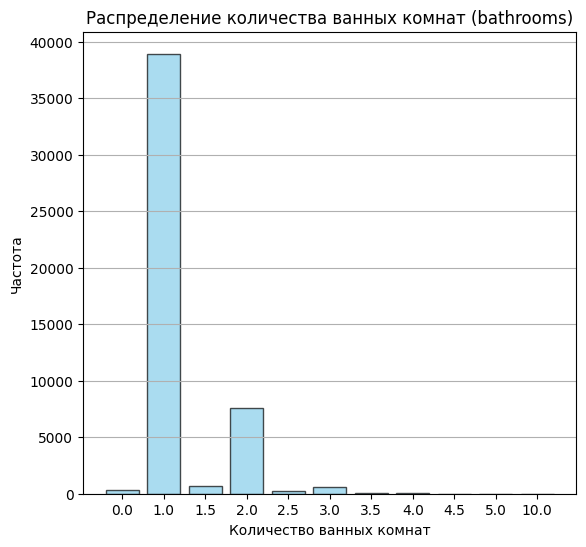

In [329]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
bathrooms_counts = df_clean['bathrooms'].value_counts().sort_index()
plt.bar(bathrooms_counts.index.astype(str), bathrooms_counts.values, 
        alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Распределение количества ванных комнат (bathrooms)')
plt.xlabel('Количество ванных комнат')
plt.ylabel('Частота')
plt.grid(axis='y')

In [330]:
df_clean

,bathrooms,bedrooms,interest_level,price,interest_level_encoded
4,1.0,1,medium,2400,1
6,1.0,2,low,3800,0
9,1.0,2,medium,3495,1
10,1.5,3,medium,3000,1
15,1.0,0,low,2795,0
...,...,...,...,...,...
124000,1.0,3,low,2800,0
124002,1.0,2,medium,2395,1
124004,1.0,1,medium,1850,1
124008,1.0,2,medium,4195,1


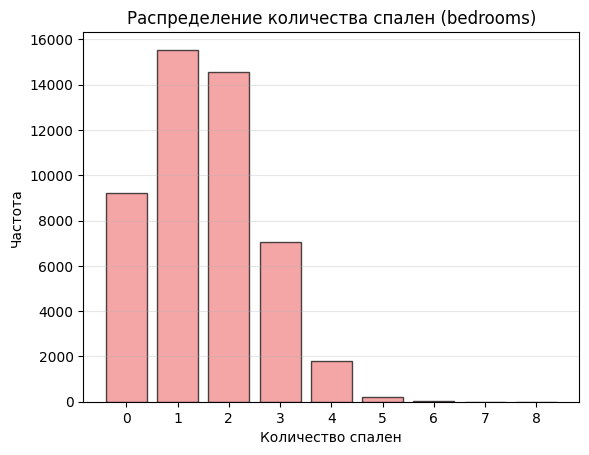

In [331]:
bedrooms_counts = df_clean['bedrooms'].value_counts().sort_index()
plt.bar(bedrooms_counts.index.astype(str), bedrooms_counts.values, 
        alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Распределение количества спален (bedrooms)')
plt.xlabel('Количество спален')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

In [332]:
df_clean['bathrooms'].describe()


count    48379.000000
mean         1.195198
std          0.456495
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: bathrooms, dtype: float64

In [333]:
df_clean['bathrooms'].value_counts().sort_index()

bathrooms
0.0       302
1.0     38928
1.5       645
2.0      7580
2.5       232
3.0       572
3.5        33
4.0        84
4.5         1
5.0         1
10.0        1
Name: count, dtype: int64

In [334]:
Q1_bath = df_clean['bathrooms'].quantile(0.25)
Q3_bath = df_clean['bathrooms'].quantile(0.75)
IQR_bath = Q3_bath - Q1_bath

print(f"\nQ1 (25-й процентиль) bathrooms: {Q1_bath}")
print(f"Q3 (75-й процентиль) bathrooms: {Q3_bath}")
print(f"IQR: {IQR_bath}")


Q1 (25-й процентиль) bathrooms: 1.0
Q3 (75-й процентиль) bathrooms: 1.0
IQR: 0.0


**Выбросов не наблюдаем**

In [335]:
lower_bound_bath = 0.5 # не может быть 0 ванных комнат
upper_bound_bath = 5

outliers_bath = df_clean[(df_clean['bathrooms'] < lower_bound_bath) | 
                         (df_clean['bathrooms'] > upper_bound_bath)]

print(f"Количество выбросов в bathrooms: {len(outliers_bath)}")
print(f"Процент выбросов: {len(outliers_bath)/len(df_clean)*100:.2f}%")

Количество выбросов в bathrooms: 303
Процент выбросов: 0.63%


In [336]:
if len(outliers_bath) > 0:
    print("Значения выбросов в bathrooms:")
    print(outliers_bath['bathrooms'].value_counts().sort_index())

Значения выбросов в bathrooms:
bathrooms
0.0     302
10.0      1
Name: count, dtype: int64


**10 ванных как какая-то аномалия**.   
Нет, ну в каком-то дворце, конечно, может, но тут мы это почистим)

In [337]:
print("Анализ признака 'bedrooms':")
print(df_clean['bedrooms'].describe())
print(f"\nУникальные значения bedrooms:")
print(df_clean['bedrooms'].value_counts().sort_index())

Анализ признака 'bedrooms':
count    48379.000000
mean         1.534633
std          1.101477
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: bedrooms, dtype: float64

Уникальные значения bedrooms:
bedrooms
0     9201
1    15540
2    14546
3     7061
4     1778
5      206
6       44
7        1
8        2
Name: count, dtype: int64


In [338]:
Q1_bed = df_clean['bedrooms'].quantile(0.25)
Q3_bed = df_clean['bedrooms'].quantile(0.75)
IQR_bed = Q3_bed - Q1_bed
print(f"\nQ1 (25-й процентиль) bedrooms: {Q1_bed}")
print(f"Q3 (75-й процентиль) bedrooms: {Q3_bed}")
print(f"IQR: {IQR_bed}")


Q1 (25-й процентиль) bedrooms: 1.0
Q3 (75-й процентиль) bedrooms: 2.0
IQR: 1.0


Почти аналогичная ситуация

In [339]:
lower_bound_bed = 0 # если студия - такова реальность в наше время))
upper_bound_bed = 10

outliers_bed = df_clean[(df_clean['bedrooms'] < lower_bound_bed) | 
                        (df_clean['bedrooms'] > upper_bound_bed)]

print(f"Количество выбросов в bedrooms: {len(outliers_bed)}")
print(f"Процент выбросов: {len(outliers_bed)/len(df_clean)*100:.2f}%")

Количество выбросов в bedrooms: 0
Процент выбросов: 0.00%


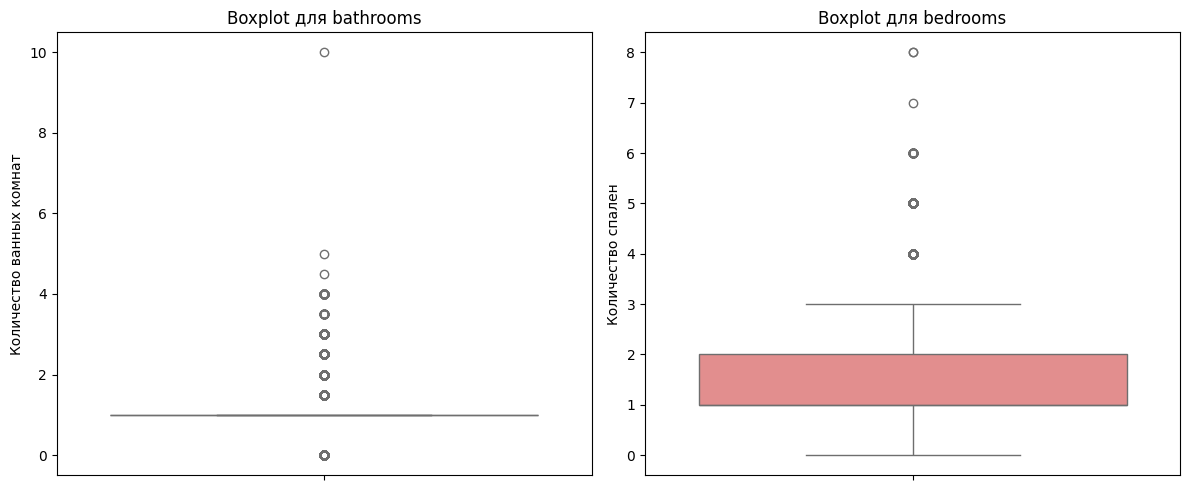

In [340]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['bathrooms'], color='skyblue')
plt.title('Boxplot для bathrooms')
plt.ylabel('Количество ванных комнат')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['bedrooms'], color='lightcoral')
plt.title('Boxplot для bedrooms')
plt.ylabel('Количество спален')

plt.tight_layout()
plt.show()


Ничего критичного по боксплоту не видно)

In [341]:
df_final = df_clean.copy()

In [342]:
df_final[['bathrooms', 'bedrooms', 'price', 'interest_level_encoded']].describe()

,bathrooms,bedrooms,price,interest_level_encoded
count,48379.000000,48379.000000,48379.000000,48379.000000
mean,1.195198,1.534633,3538.636888,0.377188
std,0.456495,1.101477,1597.663167,0.618340
min,0.000000,0.000000,1475.000000,0.000000
25%,1.000000,1.000000,2500.000000,0.000000
50%,1.000000,1.000000,3150.000000,0.000000
75%,1.000000,2.000000,4065.000000,1.000000
max,10.000000,8.000000,13000.000000,2.000000


### Complex

In [343]:
numeric_cols = ['bathrooms', 'bedrooms', 'price', 'interest_level_encoded']
correlation_matrix = df_final[numeric_cols].corr()

correlation_matrix

,bathrooms,bedrooms,price,interest_level_encoded
bathrooms,1.000000,0.517574,0.671943,-0.063635
bedrooms,0.517574,1.000000,0.545948,0.050654
price,0.671943,0.545948,1.000000,-0.200111
interest_level_encoded,-0.063635,0.050654,-0.200111,1.000000


Сильная корреляция с ванными комнатами: чем больше ванных комнат, тем выше цена. Также наблюдается корреляция с количеством комнат, но чуть меньше, чем с ванными комнатами. Также корреляция между количеством комнат и ванных, чем больше комнат, тем больше ванных комнат, что тоже выглядит логично. 

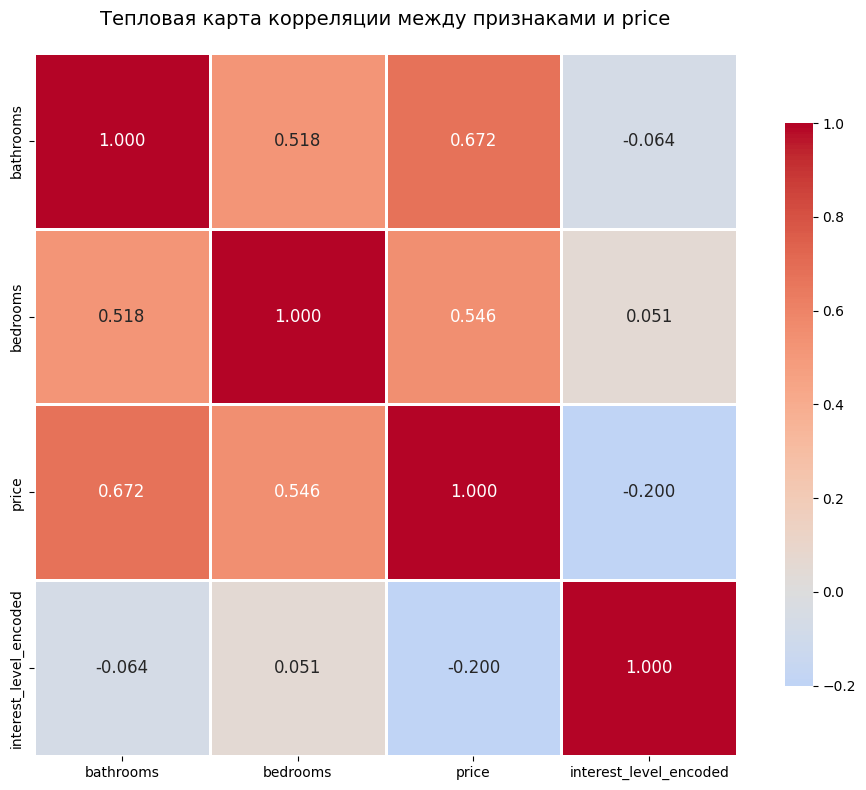

In [344]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  
            cmap='coolwarm',  
            center=0,  
            square=True,  
            linewidths=1,  
            cbar_kws={"shrink": 0.8},  
            fmt='.3f',  
            annot_kws={'size': 12}) 

plt.title('Тепловая карта корреляции между признаками и price', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

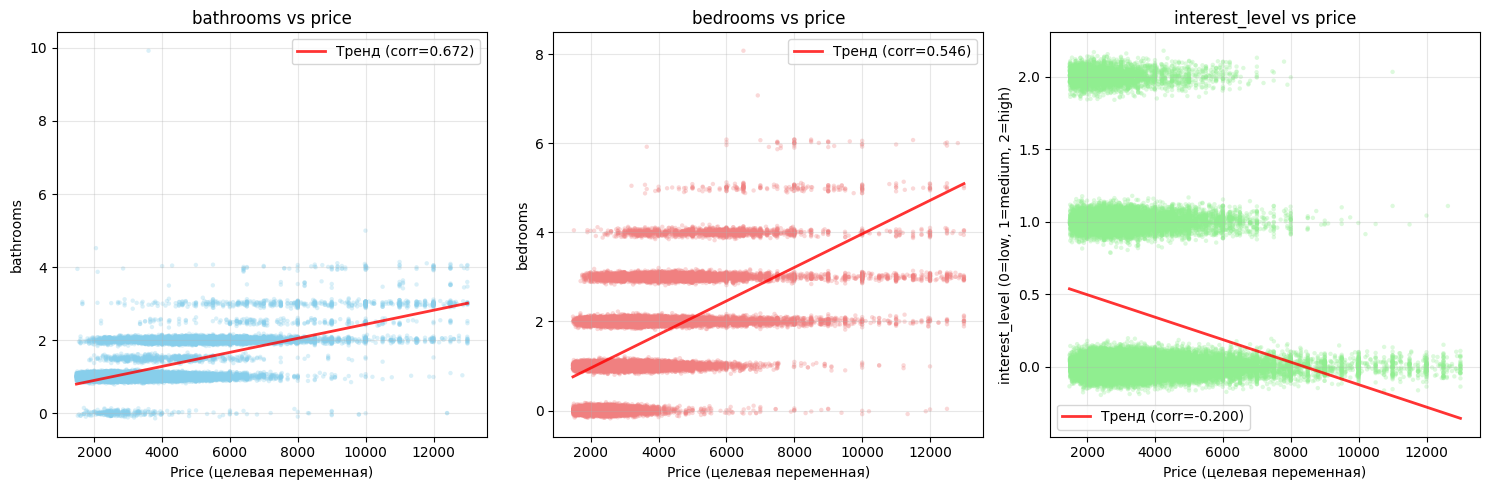

In [345]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
jitter = np.random.normal(0, 0.05, size=len(df_final))
plt.scatter(df_final['price'], df_final['bathrooms'] + jitter, 
           alpha=0.3, s=10, c='skyblue', edgecolors='none')
plt.title('bathrooms vs price')
plt.xlabel('Price (целевая переменная)')
plt.ylabel('bathrooms')
plt.grid(True, alpha=0.3)

z = np.polyfit(df_final['price'], df_final['bathrooms'], 1)
p = np.poly1d(z)
plt.plot(df_final['price'].sort_values(), p(df_final['price'].sort_values()), 
         "r-", alpha=0.8, linewidth=2, label=f'Тренд (corr={correlation_matrix.loc["bathrooms", "price"]:.3f})')
plt.legend()

plt.subplot(1, 3, 2)
jitter = np.random.normal(0, 0.05, size=len(df_final))
plt.scatter(df_final['price'], df_final['bedrooms'] + jitter, 
           alpha=0.3, s=10, c='lightcoral', edgecolors='none')
plt.title('bedrooms vs price')
plt.xlabel('Price (целевая переменная)')
plt.ylabel('bedrooms')
plt.grid(True, alpha=0.3)

z = np.polyfit(df_final['price'], df_final['bedrooms'], 1)
p = np.poly1d(z)
plt.plot(df_final['price'].sort_values(), p(df_final['price'].sort_values()), 
         "r-", alpha=0.8, linewidth=2, label=f'Тренд (corr={correlation_matrix.loc["bedrooms", "price"]:.3f})')
plt.legend()

plt.subplot(1, 3, 3)
jitter = np.random.normal(0, 0.05, size=len(df_final))
plt.scatter(df_final['price'], df_final['interest_level_encoded'] + jitter, 
           alpha=0.3, s=10, c='lightgreen', edgecolors='none')
plt.title('interest_level vs price')
plt.xlabel('Price (целевая переменная)')
plt.ylabel('interest_level (0=low, 1=medium, 2=high)')
plt.grid(True, alpha=0.3)

z = np.polyfit(df_final['price'], df_final['interest_level_encoded'], 1)
p = np.poly1d(z)
plt.plot(df_final['price'].sort_values(), p(df_final['price'].sort_values()), 
         "r-", alpha=0.8, linewidth=2, label=f'Тренд (corr={correlation_matrix.loc["interest_level_encoded", "price"]:.3f})')
plt.legend()

plt.tight_layout()
plt.show()

**Посмотрим на средние цены по разным категориям**

In [346]:
bathroom_price = df_final.groupby('bathrooms')['price'].agg(['mean', 'count', 'std']).round(2)
print(bathroom_price)

print("\nСредняя цена по количеству спален:")
bedroom_price = df_final.groupby('bedrooms')['price'].agg(['mean', 'count', 'std']).round(2)
print(bedroom_price)

print("\nСредняя цена по уровню интереса:")
interest_price = df_final.groupby('interest_level')['price'].agg(['mean', 'count', 'std']).round(2)
print(interest_price)

              mean  count      std
bathrooms                         
0.0        3236.82    302  1678.35
1.0        3048.62  38928   948.23
1.5        4257.07    645  1351.29
2.0        5405.31   7580  1690.20
2.5        7651.07    232  2267.16
3.0        8598.13    572  2622.50
3.5        9990.61     33  2322.06
4.0        9346.25     84  2657.35
4.5        2050.00      1      NaN
5.0        9995.00      1      NaN
10.0       3600.00      1      NaN

Средняя цена по количеству спален:
             mean  count      std
bedrooms                         
0         2496.33   9201   671.34
1         3075.32  15540   952.29
2         3753.91  14546  1527.57
3         4754.55   7061  1930.91
4         5768.31   1778  1781.15
5         7778.79    206  2233.22
6         8599.30     44  1857.16
7         6923.00      1      NaN
8         8247.50      2  2471.34

Средняя цена по уровню интереса:
                   mean  count      std
interest_level                         
high            2771.

**Красивая визуализация для понимания**

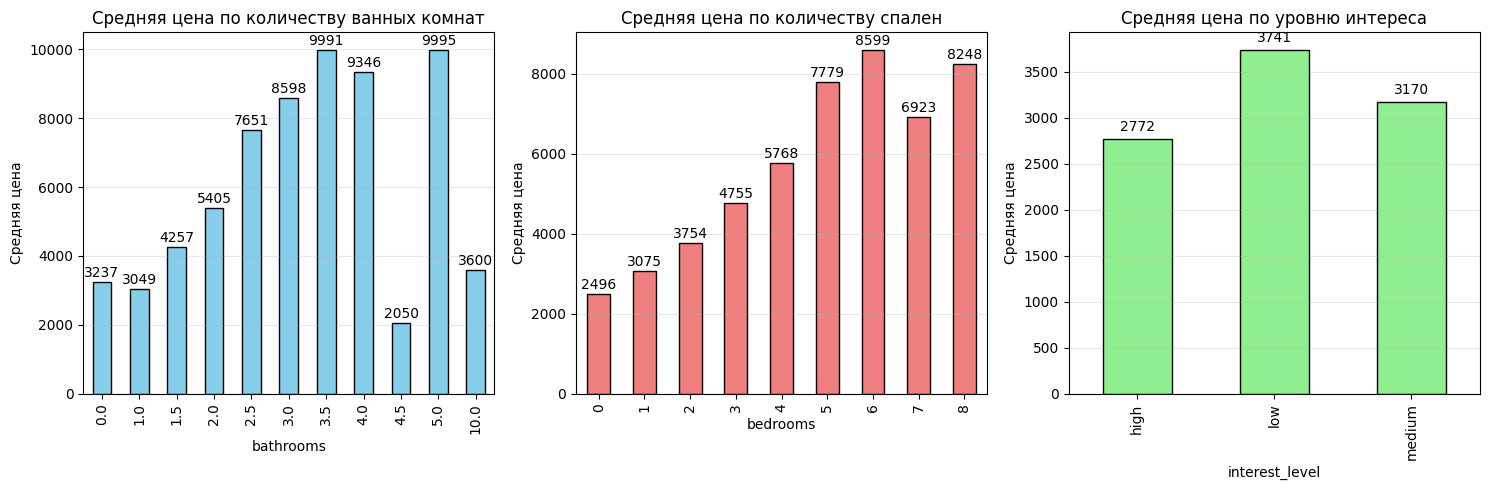

In [347]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
bathroom_price['mean'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Средняя цена по количеству ванных комнат')
plt.xlabel('bathrooms')
plt.ylabel('Средняя цена')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(bathroom_price['mean']):
    plt.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom')

plt.subplot(1, 3, 2)
bedroom_price['mean'].plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Средняя цена по количеству спален')
plt.xlabel('bedrooms')
plt.ylabel('Средняя цена')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(bedroom_price['mean']):
    plt.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom')

plt.subplot(1, 3, 3)
interest_price['mean'].plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Средняя цена по уровню интереса')
plt.xlabel('interest_level')
plt.ylabel('Средняя цена')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(interest_price['mean']):
    plt.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Creating Features


Создала 3 новых признака — квадраты исходных: bathrooms_squared, bedrooms_squared, interest_level_squared. Построила корреляционную матрицу с новыми признаками.   


In [348]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [349]:
df_final['bathrooms_squared'] = df_final['bathrooms'] ** 2
df_final['bedrooms_squared'] = df_final['bedrooms'] ** 2
df_final['interest_level_squared'] = df_final['interest_level_encoded'] ** 2
df_final

,bathrooms,bedrooms,interest_level,price,interest_level_encoded,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,medium,2400,1,1.00,1,1
6,1.0,2,low,3800,0,1.00,4,0
9,1.0,2,medium,3495,1,1.00,4,1
10,1.5,3,medium,3000,1,2.25,9,1
15,1.0,0,low,2795,0,1.00,0,0
...,...,...,...,...,...,...,...,...
124000,1.0,3,low,2800,0,1.00,9,0
124002,1.0,2,medium,2395,1,1.00,4,1
124004,1.0,1,medium,1850,1,1.00,1,1
124008,1.0,2,medium,4195,1,1.00,4,1


In [350]:
all_features = ['bathrooms', 'bedrooms', 'interest_level_encoded', 'price',
                'bathrooms_squared', 'bedrooms_squared', 'interest_level_squared']

correlation_matrix_new = df_final[all_features].corr()

In [351]:
correlation_matrix_new

,bathrooms,bedrooms,interest_level_encoded,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517574,-0.063635,0.671943,0.956023,0.548760,-0.059410
bedrooms,0.517574,1.000000,0.050654,0.545948,0.478817,0.928277,0.039511
interest_level_encoded,-0.063635,0.050654,1.000000,-0.200111,-0.068558,0.046340,0.944013
price,0.671943,0.545948,-0.200111,1.000000,0.648486,0.543406,-0.182672
bathrooms_squared,0.956023,0.478817,-0.068558,0.648486,1.000000,0.522227,-0.062240
bedrooms_squared,0.548760,0.928277,0.046340,0.543406,0.522227,1.000000,0.035718
interest_level_squared,-0.059410,0.039511,0.944013,-0.182672,-0.062240,0.035718,1.000000


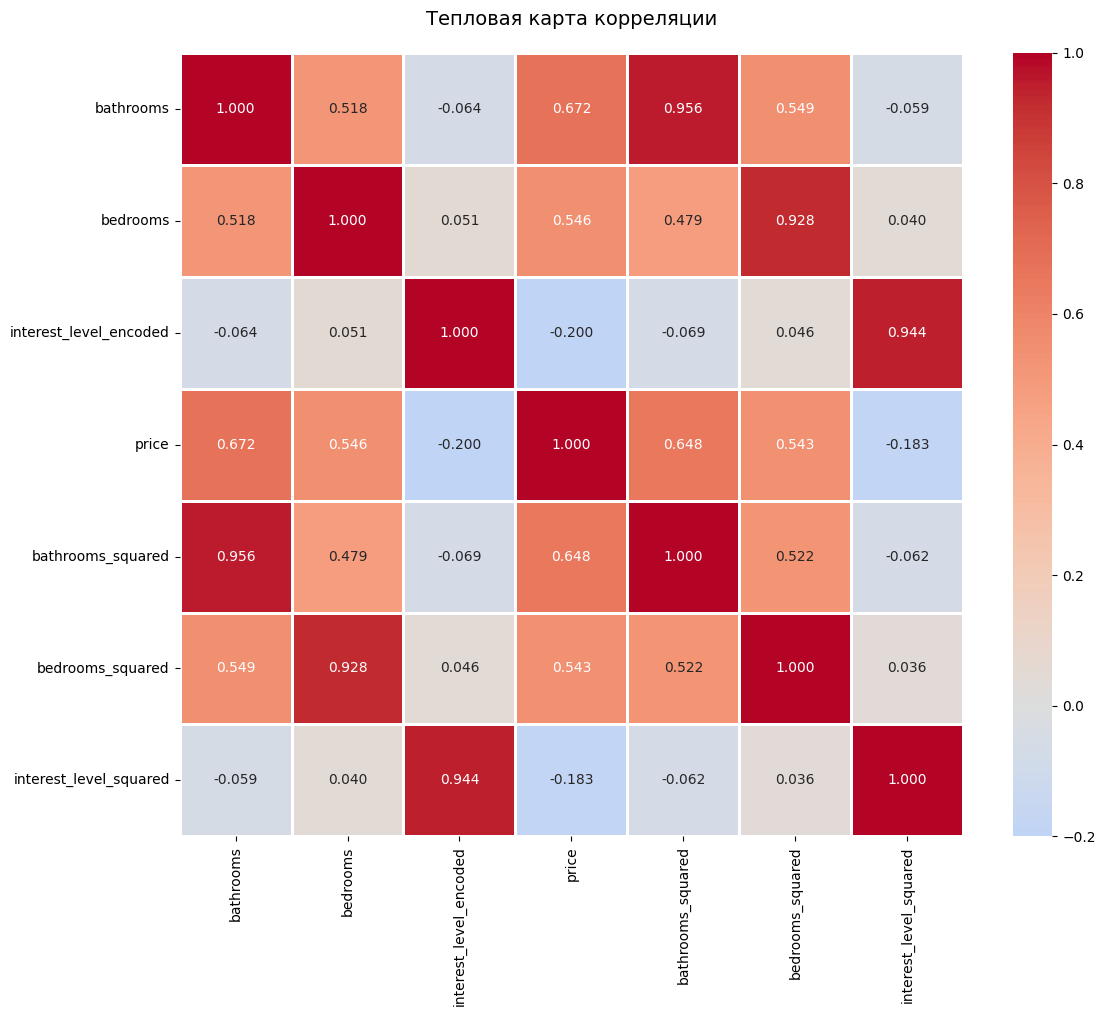

In [352]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_new, 
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            fmt='.3f',
            annot_kws={'size': 10})
plt.title('Тепловая карта корреляции', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [353]:
basic_corr = {
    'bathrooms': correlation_matrix_new.loc['bathrooms', 'price'],
    'bedrooms': correlation_matrix_new.loc['bedrooms', 'price'],
    'interest_level': correlation_matrix_new.loc['interest_level_encoded', 'price']
}

new_corr = {
    'bathrooms_squared': correlation_matrix_new.loc['bathrooms_squared', 'price'],
    'bedrooms_squared': correlation_matrix_new.loc['bedrooms_squared', 'price'],
    'interest_level_squared': correlation_matrix_new.loc['interest_level_squared', 'price']
}
for feature, corr in basic_corr.items():
    print(f"{feature}: {corr:.4f}")

bathrooms: 0.6719
bedrooms: 0.5459
interest_level: -0.2001


In [354]:
for feature, corr in new_corr.items():
    print(f"{feature}: {corr:.4f}")

bathrooms_squared: 0.6485
bedrooms_squared: 0.5434
interest_level_squared: -0.1827


In [355]:
for basic, new in zip(basic_corr.keys(), new_corr.keys()):
    diff = new_corr[new] - basic_corr[basic]
    better = "лучше" if abs(new_corr[new]) > abs(basic_corr[basic]) else "хуже"
    print(f"{basic}: {basic_corr[basic]:.4f} vs {new}: {new_corr[new]:.4f} -> {better} (разница: {diff:.4f})")

bathrooms: 0.6719 vs bathrooms_squared: 0.6485 -> хуже (разница: -0.0235)
bedrooms: 0.5459 vs bedrooms_squared: 0.5434 -> хуже (разница: -0.0025)
interest_level: -0.2001 vs interest_level_squared: -0.1827 -> хуже (разница: 0.0174)


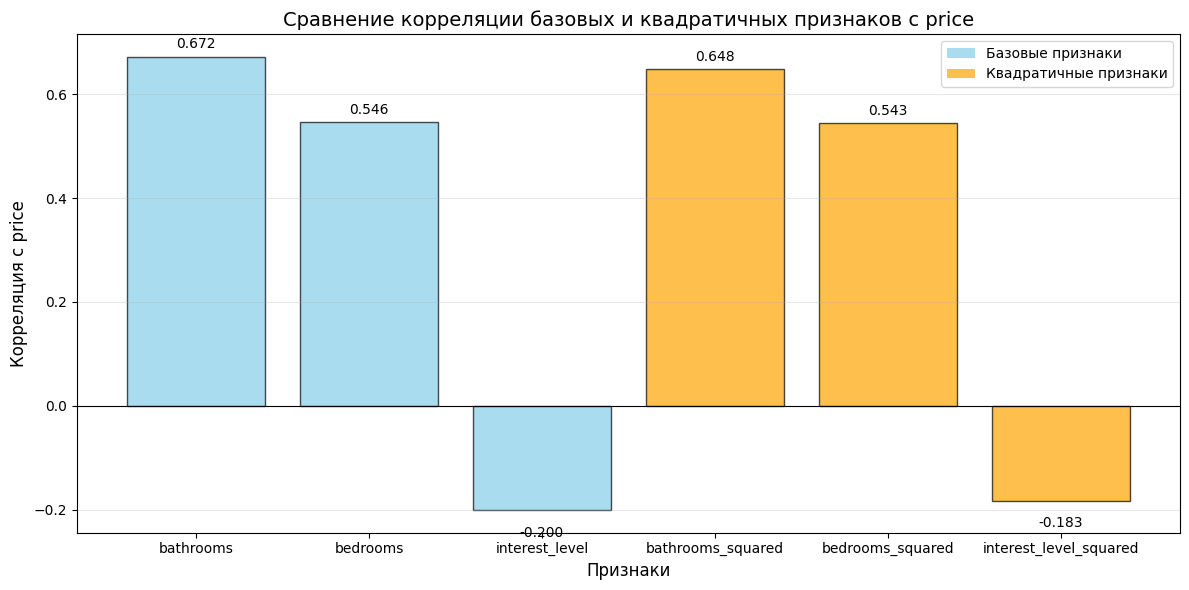

In [356]:
plt.figure(figsize=(12, 6))

features = list(basic_corr.keys()) + list(new_corr.keys())
correlations = list(basic_corr.values()) + list(new_corr.values())
colors = ['skyblue', 'skyblue', 'skyblue', 'orange', 'orange', 'orange']

bars = plt.bar(features, correlations, color=colors, edgecolor='black', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.title('Сравнение корреляции базовых и квадратичных признаков с price', fontsize=14)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Корреляция с price', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, correlations):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01 if val > 0 else height - 0.03,
             f'{val:.3f}', ha='center', va='bottom' if val > 0 else 'top', fontsize=10)


from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='skyblue', alpha=0.7, label='Базовые признаки'),
                   Patch(facecolor='orange', alpha=0.7, label='Квадратичные признаки')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

С квадратными признаками корреляция хуже. Поэтому их мы не берем)

### Обучение

Для обучения модели взяла только bathrooms и bedrooms. Разделила данные на обучающую и тестовую выборки. Инициализировала PolynomialFeatures(degree=10) и применила fit_transform к обучающим и тестовым данным — получила множество полиномиальных комбинаций признаков до степени 10.

In [357]:
X = df_final[['bathrooms', 'bedrooms']].values
y = df_final['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [358]:
print(f"\nРазмер обучающей выборки (X_train): {X_train.shape}")
print(f"Размер тестовой выборки (X_test): {X_test.shape}")
print(f"Размер целевой переменной (y_train): {y_train.shape}")
print(f"Размер целевой переменной (y_test): {y_test.shape}")


Размер обучающей выборки (X_train): (38703, 2)
Размер тестовой выборки (X_test): (9676, 2)
Размер целевой переменной (y_train): (38703,)
Размер целевой переменной (y_test): (9676,)


In [359]:
poly = PolynomialFeatures(degree=10, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
print(f"Размер X_train после PolynomialFeatures: {X_train_poly.shape}")

Размер X_train после PolynomialFeatures: (38703, 65)


In [360]:
X_test_poly = poly.transform(X_test)
print(f"Размер X_test после PolynomialFeatures: {X_test_poly.shape}")


Размер X_test после PolynomialFeatures: (9676, 65)


In [361]:
feature_names = poly.get_feature_names_out(['bathrooms', 'bedrooms'])

In [362]:
X_train[:3]

array([[1., 0.],
       [1., 3.],
       [1., 2.]])

In [363]:
X_train_poly[:3, :10]

array([[ 1.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.],
       [ 1.,  3.,  1.,  3.,  9.,  1.,  3.,  9., 27.,  1.],
       [ 1.,  2.,  1.,  2.,  4.,  1.,  2.,  4.,  8.,  1.]])

In [364]:
df_poly_train = pd.DataFrame(X_train_poly, columns=feature_names)


In [365]:
y_train_series = pd.Series(y_train, name='price')

sample_features = feature_names[:10]
corr_with_y = {}
for feat in sample_features:
    corr_with_y[feat] = np.corrcoef(df_poly_train[feat], y_train)[0, 1]

print("\nКорреляция полиномиальных признаков с целевой переменной (первые 10):")
for feat, corr in sorted(corr_with_y.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{feat}: {corr:.4f}")


Корреляция полиномиальных признаков с целевой переменной (первые 10):
bathrooms bedrooms: 0.6855
bathrooms: 0.6738
bathrooms^2 bedrooms: 0.6482
bathrooms^2: 0.6449
bathrooms bedrooms^2: 0.6059
bedrooms: 0.5464
bedrooms^2: 0.5448
bedrooms^3: 0.4968
bathrooms^3: 0.4313
bathrooms^4: 0.1592


Ну как-то все равно они не коррелируют)

# Models

**Создаем вспомогательный массив для хранения результатов**

In [366]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

## Linear Regression

In [367]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [368]:
X = df_final[['bathrooms', 'bedrooms']].values
y = df_final['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размеры данных:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Размеры данных:
X_train: (38703, 2)
X_test: (9676, 2)
y_train: (38703,)
y_test: (9676,)


In [369]:
lr_model = LinearRegression()

In [370]:
lr_model.fit(X_train, y_train)

print(f"Intercept (свободный член): {lr_model.intercept_:.2f}")
print(f"Coefficient for bathrooms: {lr_model.coef_[0]:.2f}")
print(f"Coefficient for bedrooms: {lr_model.coef_[1]:.2f}")

Intercept (свободный член): 701.77
Coefficient for bathrooms: 1866.84
Coefficient for bedrooms: 392.47


In [371]:
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

In [372]:
df_train = pd.DataFrame(X_train, columns=['bathrooms', 'bedrooms'])
df_train['actual_price'] = y_train
df_train['predicted_price_lr'] = y_train_pred

df_test = pd.DataFrame(X_test, columns=['bathrooms', 'bedrooms'])
df_test['actual_price'] = y_test
df_test['predicted_price_lr'] = y_test_pred

In [373]:
df_train.head()

,bathrooms,bedrooms,actual_price,predicted_price_lr
0,1.0,0.0,2295,2568.613842
1,1.0,3.0,2800,3746.010856
2,1.0,2.0,3400,3353.545185
3,1.0,1.0,2800,2961.079513
4,1.0,2.0,2300,3353.545185


In [374]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"MAE на обучающих данных: {mae_train:.2f}")
print(f"MAE на тестовых данных: {mae_test:.2f}")

MAE на обучающих данных: 783.65
MAE на тестовых данных: 786.23


In [375]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"RMSE на обучающих данных: {rmse_train:.2f}")
print(f"RMSE на тестовых данных: {rmse_test:.2f}")

RMSE на обучающих данных: 1122.32
RMSE на тестовых данных: 1130.13


**Есть редкие большие ошибки, но без сильных выбросов. Но в целом нужно больше признаков, так как модель ошибается почти на 30 процентов**

In [376]:
new_row_MAE = pd.DataFrame({
    'model': ['linear_regression'],
    'train': [mae_train],
    'test': [mae_test]
})
result_MAE = pd.concat([result_MAE, new_row_MAE], ignore_index=True)

new_row_RMSE = pd.DataFrame({
    'model': ['linear_regression'],
    'train': [rmse_train],
    'test': [rmse_test]
})
result_RMSE = pd.concat([result_RMSE, new_row_RMSE], ignore_index=True)

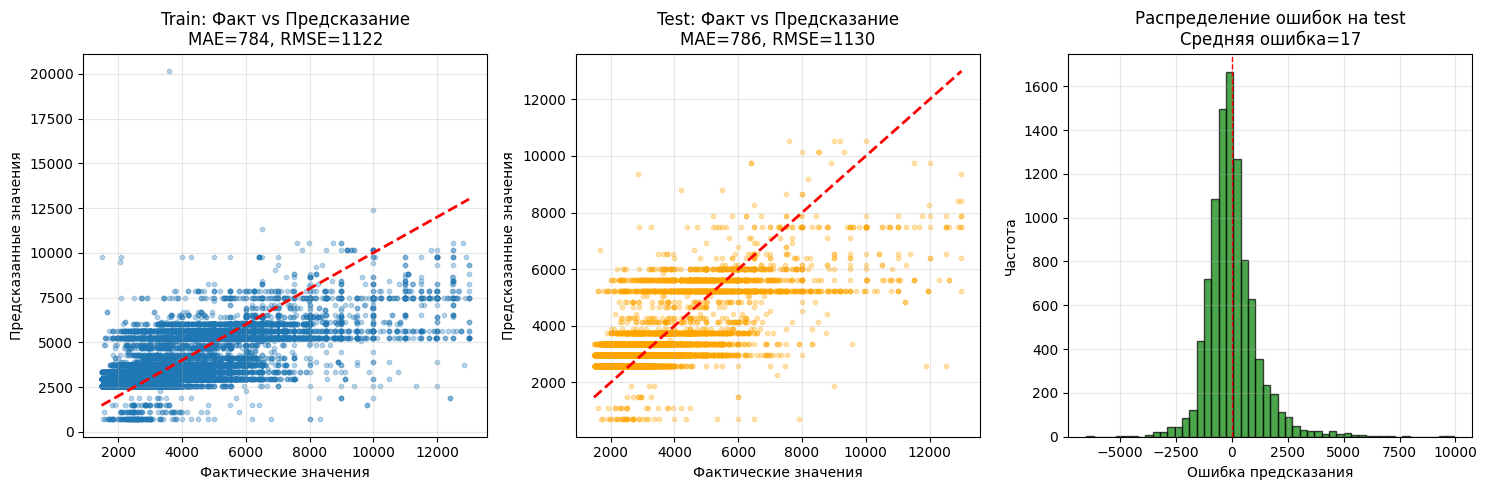

In [377]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_train, y_train_pred, alpha=0.3, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Train: Факт vs Предсказание\nMAE={mae_train:.0f}, RMSE={rmse_train:.0f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Test: Факт vs Предсказание\nMAE={mae_test:.0f}, RMSE={rmse_test:.0f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
errors = y_test - y_test_pred
plt.hist(errors, bins=50, alpha=0.7, edgecolor='black', color='green')
plt.xlabel('Ошибка предсказания')
plt.ylabel('Частота')
plt.title(f'Распределение ошибок на test\nСредняя ошибка={errors.mean():.0f}')
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


## Decision Tree

In [378]:
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [379]:
X = df_final[['bathrooms', 'bedrooms']].values
y = df_final['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [380]:
dt_model = DecisionTreeRegressor(random_state=21)
dt_model.fit(X_train, y_train)
for i, (feature, importance) in enumerate(zip(['bathrooms', 'bedrooms'], dt_model.feature_importances_)):
    print(f"  - {feature}: {importance:.4f}")

  - bathrooms: 0.8718
  - bedrooms: 0.1282


In [381]:
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt= dt_model.predict(X_test)


In [382]:
df_train_dt = pd.DataFrame(X_train, columns=['bathrooms', 'bedrooms'])
df_train_dt['actual_price'] = y_train
df_train_dt['predicted_price_lr'] = y_train_pred  
df_train_dt['predicted_price_dt'] = y_train_pred_dt

df_test_dt = pd.DataFrame(X_test, columns=['bathrooms', 'bedrooms'])
df_test_dt['actual_price'] = y_test
df_test_dt['predicted_price_lr'] = y_test_pred  
df_test_dt['predicted_price_dt'] = y_test_pred_dt

In [383]:
mae_train = mean_absolute_error(y_train, y_train_pred_dt)
mae_test = mean_absolute_error(y_test, y_test_pred_dt)

print(f"MAE на обучающих данных: {mae_train:.2f}")
print(f"MAE на тестовых данных: {mae_test:.2f}")

MAE на обучающих данных: 755.35
MAE на тестовых данных: 759.53


In [384]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))

print(f"RMSE на обучающих данных: {rmse_train:.2f}")
print(f"RMSE на тестовых данных: {rmse_test:.2f}")

RMSE на обучающих данных: 1075.21
RMSE на тестовых данных: 1089.23


В целом, ситуация похожа

In [385]:
new_row_MAE = pd.DataFrame({
    'model': ['decision_tree'],
    'train': [mae_train],
    'test': [mae_test]
})
result_MAE = pd.concat([result_MAE, new_row_MAE], ignore_index=True)

new_row_RMSE = pd.DataFrame({
    'model': ['decision_tree'],
    'train': [rmse_train],
    'test': [rmse_test]
})
result_RMSE = pd.concat([result_RMSE, new_row_RMSE], ignore_index=True)

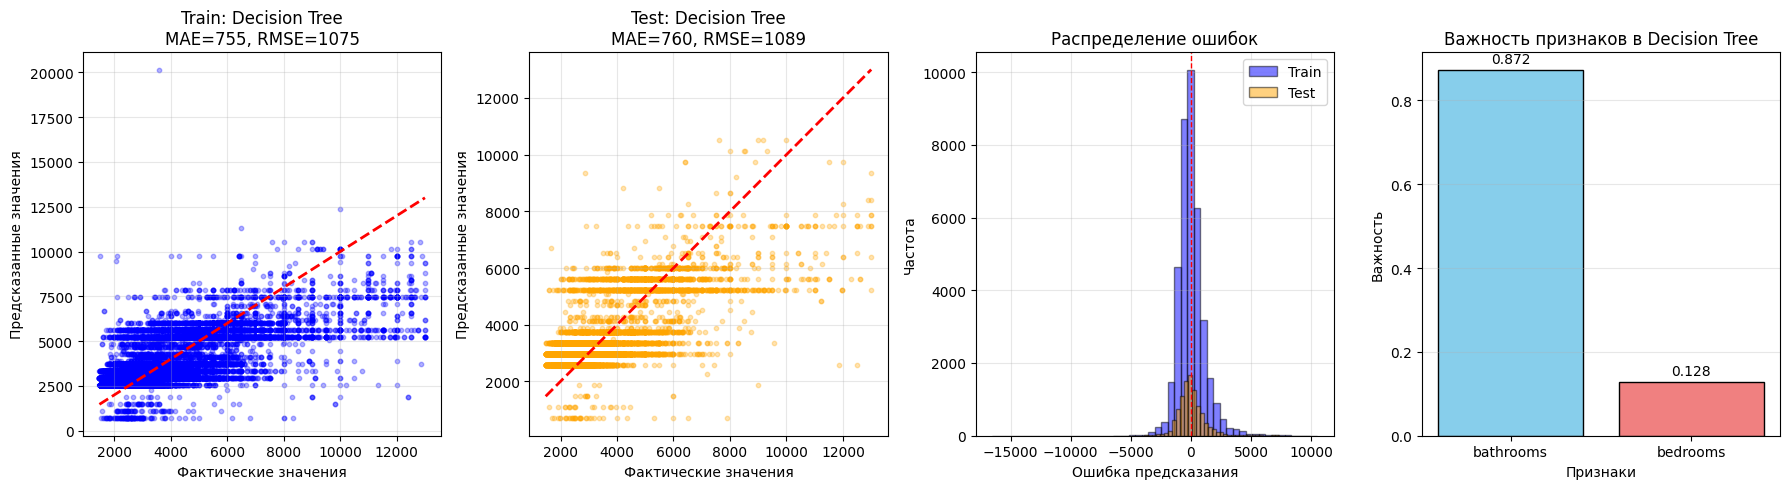

In [386]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.scatter(y_train, y_train_pred, alpha=0.3, s=10, c='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Train: Decision Tree\nMAE={mae_train:.0f}, RMSE={rmse_train:.0f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 2)
plt.scatter(y_test, y_test_pred, alpha=0.3, s=10, c='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Test: Decision Tree\nMAE={mae_test:.0f}, RMSE={rmse_test:.0f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 3)
errors_train = y_train - y_train_pred
errors_test = y_test - y_test_pred
plt.hist(errors_train, bins=50, alpha=0.5, label='Train', color='blue', edgecolor='black')
plt.hist(errors_test, bins=50, alpha=0.5, label='Test', color='orange', edgecolor='black')
plt.xlabel('Ошибка предсказания')
plt.ylabel('Частота')
plt.title('Распределение ошибок')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)

plt.subplot(1, 4, 4)
features = ['bathrooms', 'bedrooms']
importance = dt_model.feature_importances_
plt.bar(features, importance, color=['skyblue', 'lightcoral'], edgecolor='black')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков в Decision Tree')
for i, v in enumerate(importance):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##  Naive Models

In [387]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [388]:
X = df_final[['bathrooms', 'bedrooms']].values
y = df_final['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [389]:
mean_train = np.mean(y_train)
median_train = np.median(y_train)
mean_test = np.mean(y_test)
median_test = np.median(y_test)

In [390]:
df_train_naive = pd.DataFrame(X_train, columns=['bathrooms', 'bedrooms'])
df_train_naive['actual_price'] = y_train
df_train_naive['mean_prediction'] = mean_train
df_train_naive['median_prediction'] = median_train

df_test_naive = pd.DataFrame(X_test, columns=['bathrooms', 'bedrooms'])
df_test_naive['actual_price'] = y_test
df_test_naive['mean_prediction'] = mean_test
df_test_naive['median_prediction'] = median_test

In [391]:
mae_mean_train = mean_absolute_error(y_train, [mean_train] * len(y_train))
mae_mean_test = mean_absolute_error(y_test, [mean_test] * len(y_test))

mae_median_train = mean_absolute_error(y_train, [median_train] * len(y_train))
mae_median_test = mean_absolute_error(y_test, [median_test] * len(y_test))

In [392]:
print("MAE для модели 'naive_mean':")
print(f"  Train: {mae_mean_train:.2f}")
print(f"  Test: {mae_mean_test:.2f}")

print("\nMAE для модели 'naive_median':")
print(f"  Train: {mae_median_train:.2f}")
print(f"  Test: {mae_median_test:.2f}")

MAE для модели 'naive_mean':
  Train: 1137.76
  Test: 1144.89

MAE для модели 'naive_median':
  Train: 1084.59
  Test: 1092.68


In [393]:
rmse_mean_train = np.sqrt(mean_squared_error(y_train, [mean_train] * len(y_train)))
rmse_mean_test = np.sqrt(mean_squared_error(y_test, [mean_test] * len(y_test)))

rmse_median_train = np.sqrt(mean_squared_error(y_train, [median_train] * len(y_train)))
rmse_median_test = np.sqrt(mean_squared_error(y_test, [median_test] * len(y_test)))

In [394]:
new_row_MAE_mean = pd.DataFrame({
    'model': ['naive_mean'],
    'train': [mae_mean_train],
    'test': [mae_mean_test]
})
result_MAE = pd.concat([result_MAE, new_row_MAE_mean], ignore_index=True)

new_row_MAE_median = pd.DataFrame({
    'model': ['naive_median'],
    'train': [mae_median_train],
    'test': [mae_median_test]
})
result_MAE = pd.concat([result_MAE, new_row_MAE_median], ignore_index=True)

new_row_RMSE_mean = pd.DataFrame({
    'model': ['naive_mean'],
    'train': [rmse_mean_train],
    'test': [rmse_mean_test]
})
result_RMSE = pd.concat([result_RMSE, new_row_RMSE_mean], ignore_index=True)

new_row_RMSE_median = pd.DataFrame({
    'model': ['naive_median'],
    'train': [rmse_median_train],
    'test': [rmse_median_test]
})
result_RMSE = pd.concat([result_RMSE, new_row_RMSE_median], ignore_index=True)

In [395]:
result_RMSE

,model,train,test
0,linear_regression,1122.318073,1130.132148
1,decision_tree,1075.206434,1089.231913
2,naive_mean,1599.229452,1591.287957
3,naive_median,1645.449541,1635.717764


In [396]:
result_MAE

,model,train,test
0,linear_regression,783.654739,786.228746
1,decision_tree,755.352697,759.526414
2,naive_mean,1137.760556,1144.894703
3,naive_median,1084.589257,1092.676933


## Результат

In [397]:
best_mae_model = result_MAE.loc[result_MAE['test'].idxmin(), 'model']
best_mae_value = result_MAE['test'].min()

best_rmse_model = result_RMSE.loc[result_RMSE['test'].idxmin(), 'model']
best_rmse_value = result_RMSE['test'].min()

print(f"\nЛучшая модель по MAE на тестовых данных:")
print(f"   Модель: {best_mae_model}")
print(f"   Значение MAE: {best_mae_value:.2f}")

print(f"\nЛучшая модель по RMSE на тестовых данных:")
print(f"   Модель: {best_rmse_model}")
print(f"   Значение RMSE: {best_rmse_value:.2f}")


Лучшая модель по MAE на тестовых данных:
   Модель: decision_tree
   Значение MAE: 759.53

Лучшая модель по RMSE на тестовых данных:
   Модель: decision_tree
   Значение RMSE: 1089.23


In [398]:
result_MAE['diff_train_test'] = abs(result_MAE['train'] - result_MAE['test'])
result_RMSE['diff_train_test'] = abs(result_RMSE['train'] - result_RMSE['test'])

print("\nРазница между train и test (MAE):")
mae_diff_sorted = result_MAE.sort_values('diff_train_test').reset_index(drop=True)
for idx, row in mae_diff_sorted.iterrows():
    diff_percent = (row['diff_train_test'] / row['train']) * 100
    status = "✅ Хорошо" if diff_percent < 10 else "⚠️ Средне" if diff_percent < 20 else "❌ Сильное переобучение"
    print(f"  {row['model']:20} : разница={row['diff_train_test']:8.2f} ({diff_percent:.1f}%) - {status}")



Разница между train и test (MAE):
  linear_regression    : разница=    2.57 (0.3%) - ✅ Хорошо
  decision_tree        : разница=    4.17 (0.6%) - ✅ Хорошо
  naive_mean           : разница=    7.13 (0.6%) - ✅ Хорошо
  naive_median         : разница=    8.09 (0.7%) - ✅ Хорошо


Переобучение моделей мы не видим, разница между тестовой и тренировочной выборкой очень маленькая.

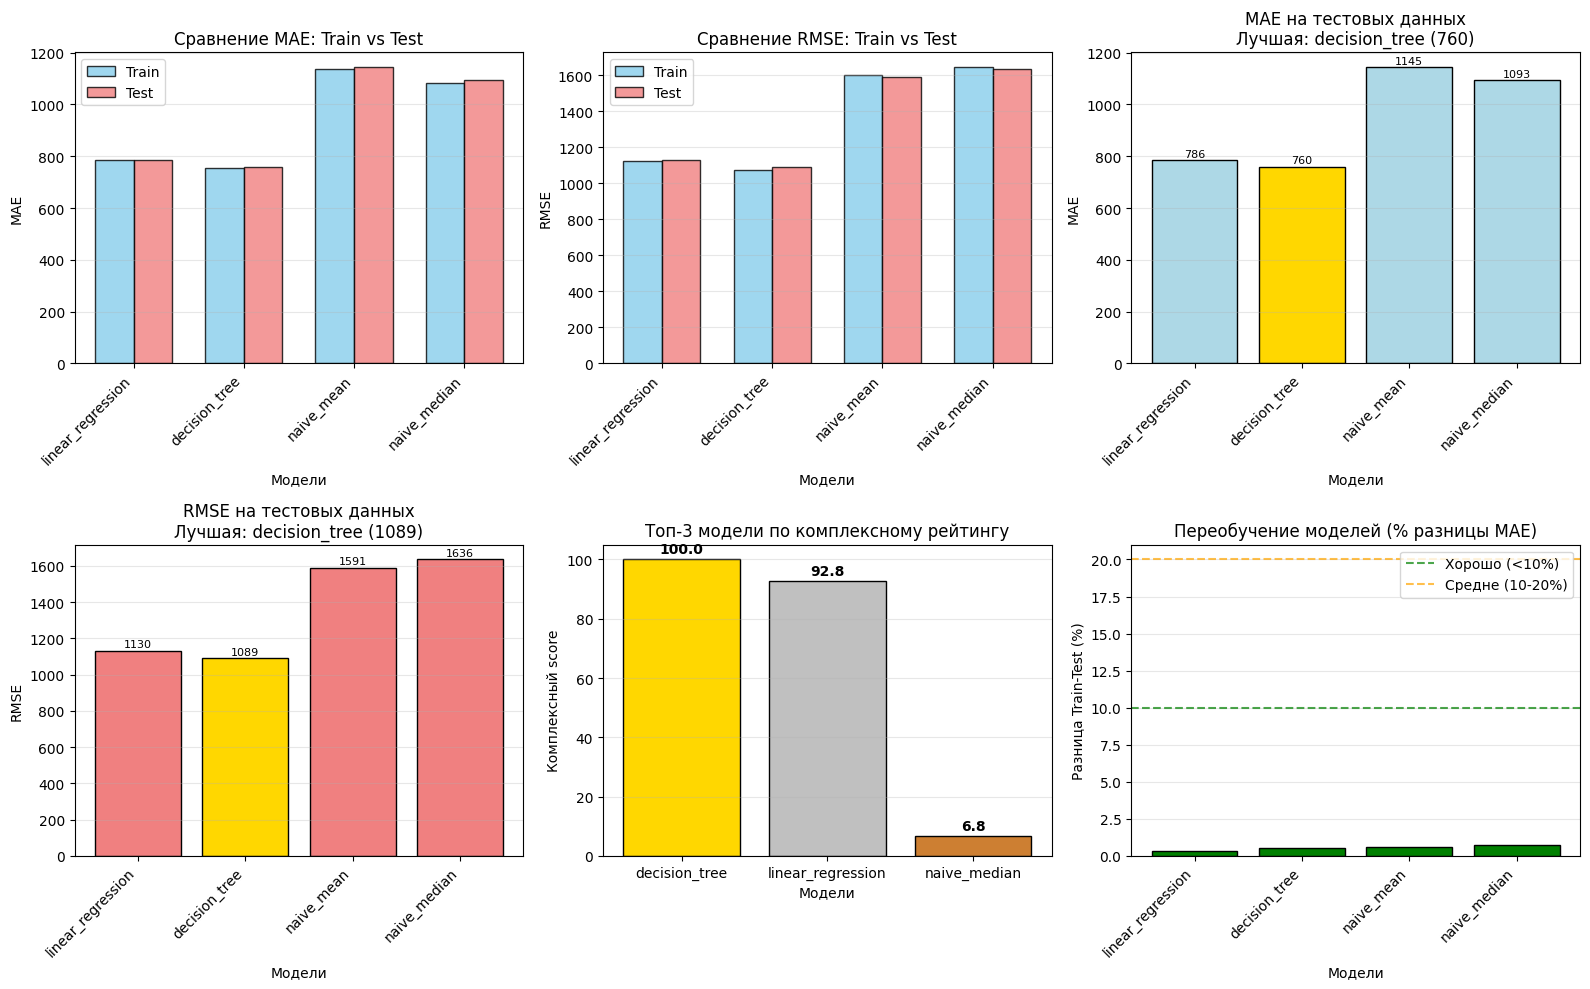

In [399]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
models = result_MAE['model'].tolist()
x = np.arange(len(models))
width = 0.35
plt.bar(x - width/2, result_MAE['train'], width, label='Train', alpha=0.8, color='skyblue', edgecolor='black')
plt.bar(x + width/2, result_MAE['test'], width, label='Test', alpha=0.8, color='lightcoral', edgecolor='black')
plt.xlabel('Модели')
plt.ylabel('MAE')
plt.title('Сравнение MAE: Train vs Test')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 2)
plt.bar(x - width/2, result_RMSE['train'], width, label='Train', alpha=0.8, color='skyblue', edgecolor='black')
plt.bar(x + width/2, result_RMSE['test'], width, label='Test', alpha=0.8, color='lightcoral', edgecolor='black')
plt.xlabel('Модели')
plt.ylabel('RMSE')
plt.title('Сравнение RMSE: Train vs Test')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 3)
colors_mae = ['gold' if m == best_mae_model else 'lightblue' for m in result_MAE['model']]
bars = plt.bar(result_MAE['model'], result_MAE['test'], color=colors_mae, edgecolor='black')
plt.xlabel('Модели')
plt.ylabel('MAE')
plt.title(f'MAE на тестовых данных\nЛучшая: {best_mae_model} ({best_mae_value:.0f})')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.0f}', ha='center', va='bottom', fontsize=8)

plt.subplot(2, 3, 4)
colors_rmse = ['gold' if m == best_rmse_model else 'lightcoral' for m in result_RMSE['model']]
bars = plt.bar(result_RMSE['model'], result_RMSE['test'], color=colors_rmse, edgecolor='black')
plt.xlabel('Модели')
plt.ylabel('RMSE')
plt.title(f'RMSE на тестовых данных\nЛучшая: {best_rmse_model} ({best_rmse_value:.0f})')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{height:.0f}', ha='center', va='bottom', fontsize=8)

plt.subplot(2, 3, 5)
top_models = comparison_sorted.head(3)
colors_top = ['gold', 'silver', '#cd7f32']  
bars = plt.bar(top_models['model'], top_models['total_score'], color=colors_top, edgecolor='black')
plt.xlabel('Модели')
plt.ylabel('Комплексный score')
plt.title('Топ-3 модели по комплексному рейтингу')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 105)

for bar, score in zip(bars, top_models['total_score']):
    plt.text(bar.get_x() + bar.get_width()/2., score + 1,
             f'{score:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.subplot(2, 3, 6)
diff_mae = result_MAE['diff_train_test'].values
diff_percent = (diff_mae / result_MAE['train'].values) * 100
bars = plt.bar(models, diff_percent, color=['red' if d > 20 else 'orange' if d > 10 else 'green' for d in diff_percent], 
               edgecolor='black')
plt.xlabel('Модели')
plt.ylabel('Разница Train-Test (%)')
plt.title('Переобучение моделей (% разницы MAE)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=10, color='green', linestyle='--', alpha=0.7, label='Хорошо (<10%)')
plt.axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='Средне (10-20%)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Из всех лучше tree. 

### На всех признаках

Пробуем оставить больше признаков в самом начале для предсказания. 

In [400]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [401]:
df_full = pd.read_json('data/train.json')

df_full['num_photos'] = df_full['photos'].apply(len)
df_full['num_features'] = df_full['features'].apply(len)
df_full['desc_length'] = df_full['description'].apply(len)
df_full['created_date'] = pd.to_datetime(df_full['created'])
df_full['day'] = df_full['created_date'].dt.day
df_full['month'] = df_full['created_date'].dt.month
df_full['hour'] = df_full['created_date'].dt.hour

features = ['bathrooms', 'bedrooms', 'num_photos', 'num_features', 
            'desc_length', 'day', 'month', 'hour', 'latitude', 'longitude']
X_all = df_full[features].values
y_all = df_full['price'].values

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [402]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [403]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\nМетрики Random Forest:")
print(f"  MAE - Train: {mae_train:.2f}, Test: {mae_test:.2f}")
print(f"  RMSE - Train: {rmse_train:.2f}, Test: {rmse_test:.2f}")


Метрики Random Forest:
  MAE - Train: 219.78, Test: 1089.69
  RMSE - Train: 3639.23, Test: 45551.53


Что-то пошло не так и модель сломалась или переобучилась, такое бывает..

In [404]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("Decision Tree:")
print(f"MAE - Train: {mae_train:.2f}, Test: {mae_test:.2f}")
print(f"RMSE - Train: {rmse_train:.2f}, Test: {rmse_test:.2f}")

Decision Tree:
MAE - Train: 555.65, Test: 1405.63
RMSE - Train: 978.55, Test: 49053.39


Что ж, пробуем пофиксить модель, уберем выбросы и попробуем еще раз.

In [405]:
df_full = pd.read_json('data/train.json')

df_full['num_photos'] = df_full['photos'].apply(len)
df_full['num_features'] = df_full['features'].apply(len)
df_full['desc_length'] = df_full['description'].apply(len)

df_full['created_date'] = pd.to_datetime(df_full['created'])
df_full['day'] = df_full['created_date'].dt.day
df_full['month'] = df_full['created_date'].dt.month
df_full['hour'] = df_full['created_date'].dt.hour

# вроде координаты правильно подобрала, но это не точно)
df_clean = df_full[
    (df_full['latitude'].between(40.4, 41.0)) &
    (df_full['longitude'].between(-74.3, -73.6))
]

low = df_clean['price'].quantile(0.01)
high = df_clean['price'].quantile(0.99)

df_clean = df_clean[
    (df_clean['price'] >= low) &
    (df_clean['price'] <= high)
]

df_clean = df_clean[df_clean['bedrooms'] <= 10]
df_clean = df_clean[df_clean['bathrooms'] <= 5]
df_clean = df_clean[df_clean['num_photos'] <= 30]


features = [
    'bathrooms', 'bedrooms',
    'num_photos', 'num_features',
    'desc_length', 'day', 'month', 'hour',
    'latitude', 'longitude'
]

X = df_clean[features].values
y = df_clean['price'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)


mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))


print("Метрики Decision Tree после удаления выбросов:")
print(f"MAE  - Train: {mae_train:.2f}, Test: {mae_test:.2f}")
print(f"RMSE - Train: {rmse_train:.2f}, Test: {rmse_test:.2f}")

Метрики Decision Tree после удаления выбросов:
MAE  - Train: 506.29, Test: 540.43
RMSE - Train: 791.51, Test: 865.12


Ошибка сильно уменьшилась, переобучения не видно. Процент ошибки по сравнению с двумя признаками тоже уменьшился, результаты +- реалистичные. Конечно лучше больше признаков использовать, но опять же нудно смотреть, так как некоторые признаки могут ухудшать результат. 